In [2]:
# ====================== 1. 读取数据 & 基础检查 ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb

In [3]:
data = pd.read_csv("data_public.csv")
X = data.drop("Class", axis=1)
y = data["Class"]

# 缺失值检查
print("缺失值统计：")
print(data.isnull().sum())

缺失值统计：
A        0
B        0
C        0
D        0
E        0
F        0
G        0
H        0
I        0
J        0
K        0
L        0
M        0
N        0
O        0
Class    0
dtype: int64


## 2. 绘制特征直方图

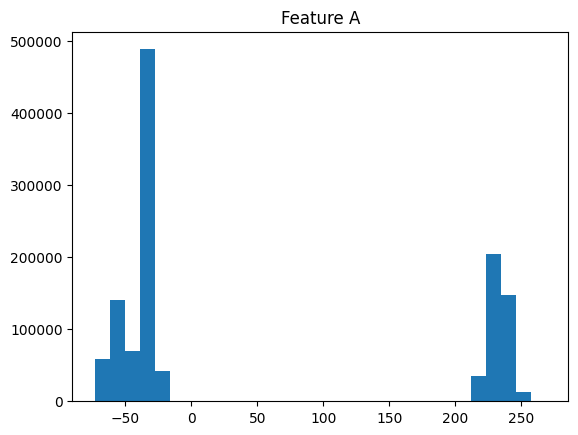

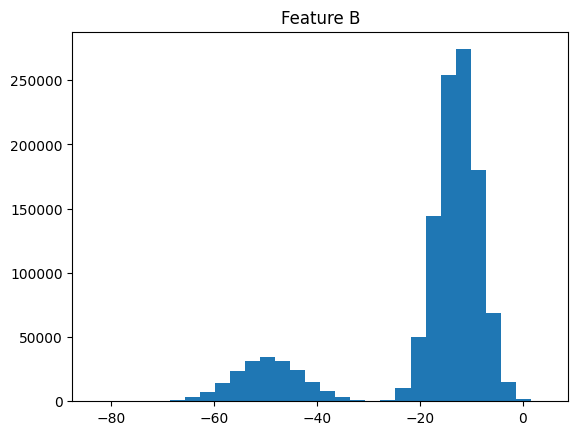

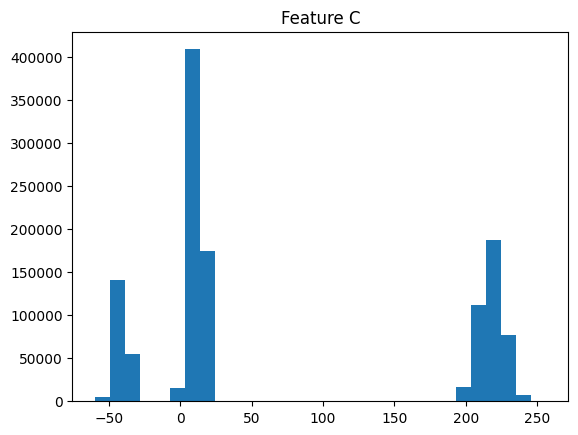

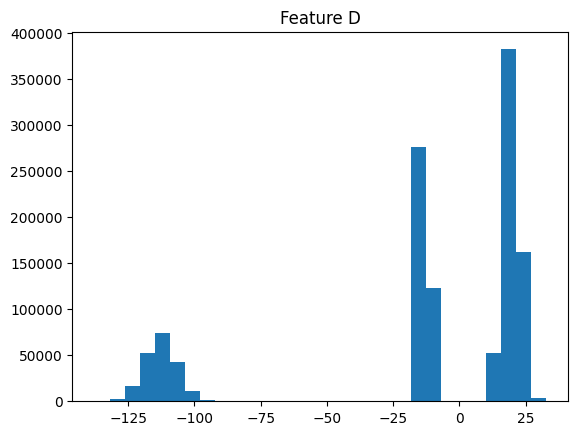

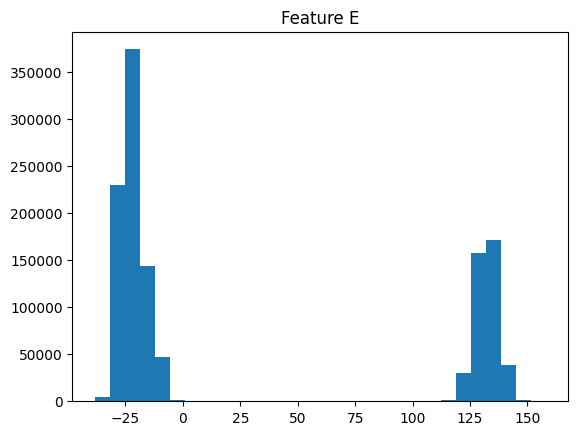

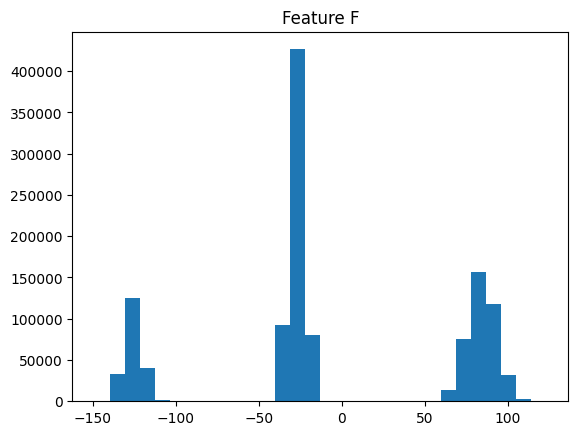

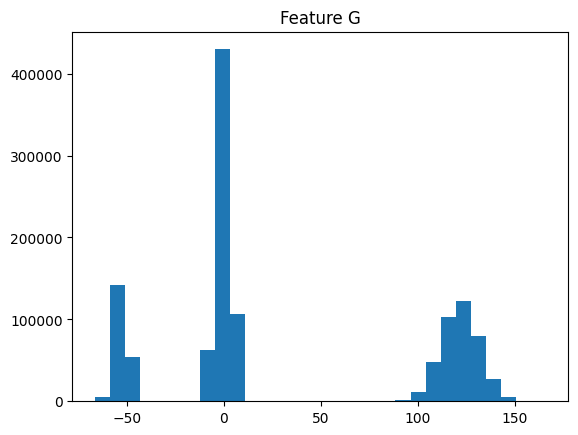

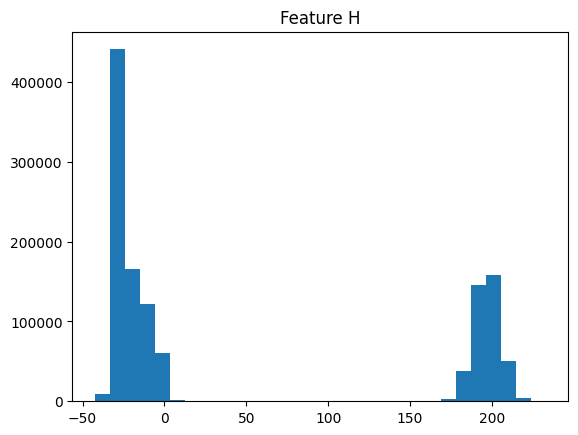

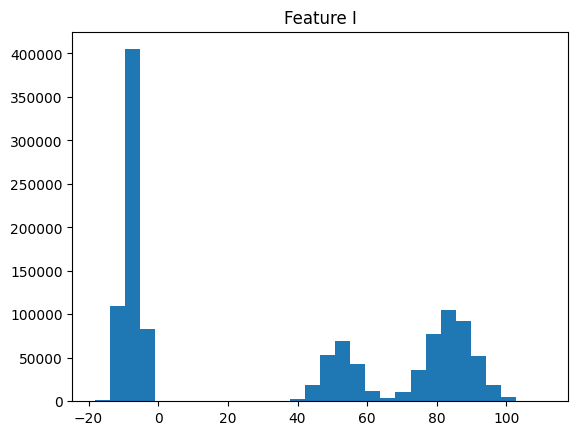

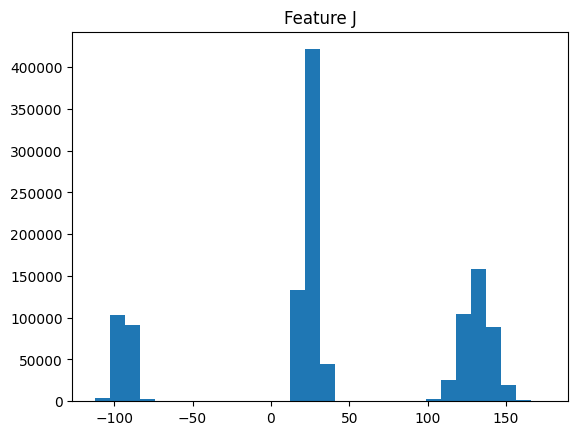

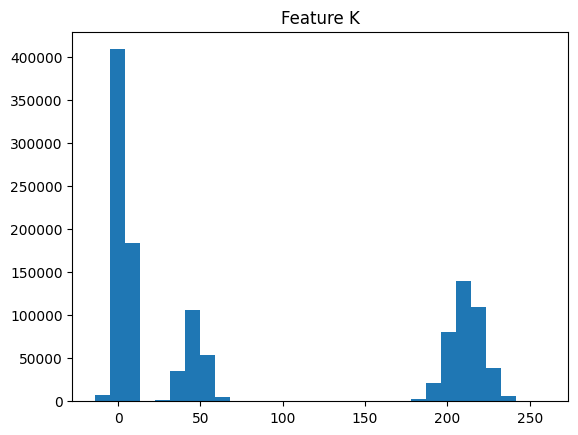

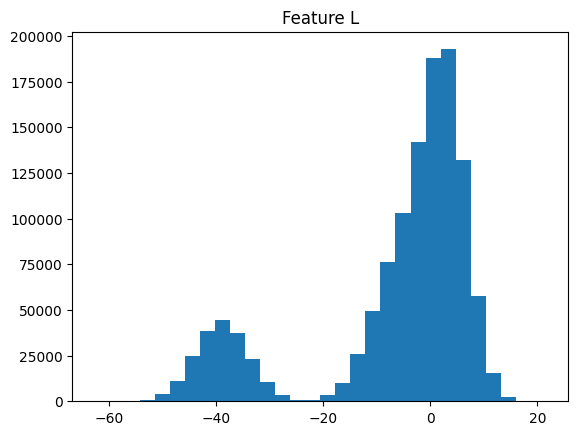

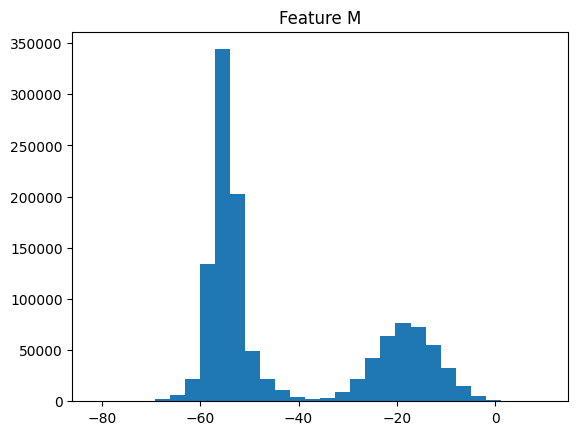

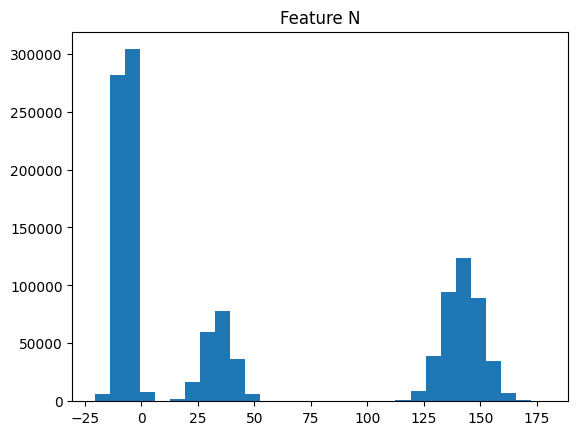

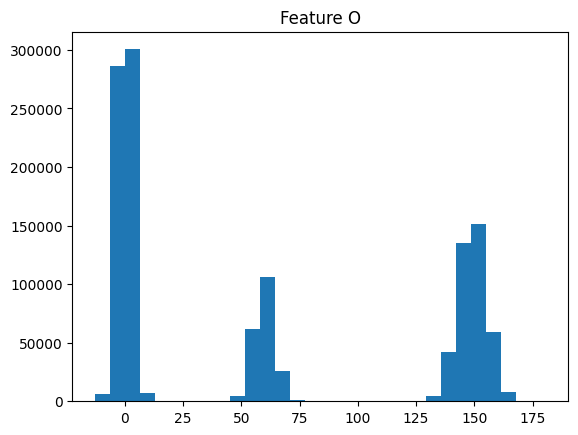

In [4]:
for col in X.columns:
    plt.hist(data[col], bins=30)
    plt.title(f"Feature {col}")
    plt.show()

## 3. 共线性特征筛选（阈值 0.98）

In [ ]:
# --- 共线性筛选：相关系数 > 0.98 的冗余特征 ---
corr = X.corr().abs()
drop_collinear = set()
for i in range(len(corr.columns)):
    for j in range(i):
        if corr.iloc[i, j] > 0.98:
            col_i, col_j = corr.columns[i], corr.columns[j]
            corr_i = abs(X[col_i].corr(y))
            corr_j = abs(X[col_j].corr(y))
            drop = col_j if corr_i >= corr_j else col_i
            drop_collinear.add(drop)

print(f"\n共线性 >0.98 剔除: {sorted(drop_collinear) if drop_collinear else '无'}")
if drop_collinear:
    X = X.drop(columns=list(drop_collinear))
print(f"剩余特征 ({X.shape[1]} 个): {list(X.columns)}")


共线性 >0.98 剔除: ['A', 'E', 'G', 'H', 'J', 'K', 'O']


## 4. LightGBM 特征重要度筛选 → 最终选 A,B,D

In [ ]:
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X, y)
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)
print("\n特征重要度：")
print(importance)

# 动态选取：剔除重要度为 0 的特征，至少保留前 3 个
nonzero = importance[importance["importance"] > 0]
n_keep = max(3, len(nonzero))
final_features = importance["feature"].iloc[:n_keep].tolist()
print(f"\n最终保留 {len(final_features)} 个特征: {final_features}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021901 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 1200000, number of used features: 15
[LightGBM] [Info] Start training from score -1.791799
[LightGBM] [Info] Start training from score -0.694435
[LightGBM] [Info] Start training from score -1.096664

特征重要度：
   feature  importance
11       L         657
2        C         650
1        B         645
3        D         618
9        J         610
6        G         609
7        H         609
4        E         607
5        F         603
14       O         601
12       M         592
13       N         563
0        A         559
10       K         552
8        I         525


## 5. 构建 Pipeline + 数据集划分

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin

class ColumnSelector(BaseEstimator, TransformerMixin):
    """替代 mlxtend.feature_selection.ColumnSelector"""
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.columns]

pipeline = Pipeline([
    ("selector", ColumnSelector(columns=final_features)),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=1)),
    ("model", RandomForestClassifier(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## 6. GridSearchCV 调参

In [8]:
param_grid = {
    "model__max_depth": [1, 2, 3, 4],
    "model__n_estimators": [1, 5, 10, 20, 50, 100, 1000]
}
grid = GridSearchCV(pipeline, param_grid, cv=4)
grid.fit(X_train, y_train)
print("\n最优参数：", grid.best_params_)


最优参数： {'model__max_depth': 3, 'model__n_estimators': 10}


## 7. 训练最优模型 & 评估

In [9]:
best_pipeline = grid.best_estimator_
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n测试集准确率: {acc:.4f}")
print("\n分类报告：")
print(classification_report(y_test, y_pred))


测试集准确率: 0.4994

分类报告：
              precision    recall  f1-score   support

           1       0.00      0.00      0.00     60096
           2       0.50      1.00      0.67    179770
           3       0.36      0.00      0.00    120134

    accuracy                           0.50    360000
   macro avg       0.29      0.33      0.22    360000
weighted avg       0.37      0.50      0.33    360000



c:\Users\94824\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\94824\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\94824\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 8. 交叉验证

In [10]:
cv_scores = cross_val_score(best_pipeline, X, y, cv=6)
print("\n6折交叉验证得分：", cv_scores)
print("交叉验证平均分：", cv_scores.mean())


6折交叉验证得分： [0.49936  0.49936  0.499355 0.499355 0.499355 0.499355]
交叉验证平均分： 0.49935666666666667


## 9. ONNX 转换（尝试）

In [11]:
try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    import onnxruntime as rt

    initial_type = [("float_input", FloatTensorType([None, len(final_features)]))]
    onnx_model = convert_sklearn(best_pipeline, initial_types=initial_type)

    with open("model.onnx", "wb") as f:
        f.write(onnx_model.SerializeToString())

    # 验证推理
    sess = rt.InferenceSession("model.onnx")
    input_name = sess.get_inputs()[0].name
    test_np = X_test[final_features].values.astype(np.float32)
    pred_onnx = sess.run(None, {input_name: test_np})[0]
    print("\nONNX 推理成功！")
except Exception as e:
    print("\nONNX 转换失败（原文问题）：", e)


ONNX 转换失败（原文问题）： Unable to find a shape calculator for type '<class '__main__.ColumnSelector'>'.
It usually means the pipeline being converted contains a
transformer or a predictor with no corresponding converter
implemented in sklearn-onnx. If the converted is implemented
in another library, you need to register
the converted so that it can be used by sklearn-onnx (function
update_registered_converter). If the model is not yet covered
by sklearn-onnx, you may raise an issue to
https://github.com/onnx/sklearn-onnx/issues
to get the converter implemented or even contribute to the
project. If the model is a custom model, a new converter must
be implemented. Examples can be found in the gallery.



In [12]:
# ====================== 1. 读取数据 & 基础检查 ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from feature_selector import FeatureSelector
from mlxtend.feature_selection import ColumnSelector
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import lightgbm as lgb

ModuleNotFoundError: No module named 'feature_selector'

In [ ]:
data = pd.read_csv("data_public.csv.gz")
X = data.drop("Class", axis=1)
y = data["Class"]

# 缺失值检查
print("缺失值统计：")
print(data.isnull().sum())

## 2. 绘制特征直方图

In [ ]:
for col in X.columns:
    plt.hist(data[col], bins=30)
    plt.title(f"Feature {col}")
    plt.show()

## 3. 共线性特征筛选（阈值 0.98）

In [ ]:
fs = FeatureSelector(data=X, labels=y)
fs.identify_collinear(correlation_threshold=0.98)
print("\n共线特征记录：")
print(fs.record_collinear)

# 筛选后保留特征：A,B,D,I,L,M
features_kept = ["A", "B", "D", "I", "L", "M"]

## 4. LightGBM 特征重要度筛选

In [ ]:
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X, y)
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)
print("\n特征重要度：")
print(importance)

# 最终最优特征：A,B,D
final_features = ["A", "B", "D"]

## 5. 构建 Pipeline + 数据集划分

In [ ]:
pipeline = Pipeline([
    ("selector", ColumnSelector(columns=final_features)),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=1)),
    ("model", RandomForestClassifier(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## 6. GridSearchCV 调参

In [ ]:
param_grid = {
    "model__max_depth": [1, 2, 3, 4],
    "model__n_estimators": [1, 5, 10, 20, 50, 100, 1000]
}
grid = GridSearchCV(pipeline, param_grid, cv=4)
grid.fit(X_train, y_train)
print("\n最优参数：", grid.best_params_)

## 7. 训练最优模型 & 评估

In [ ]:
best_pipeline = grid.best_estimator_
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n测试集准确率: {acc:.4f}")
print("\n分类报告：")
print(classification_report(y_test, y_pred))

## 8. 交叉验证

In [ ]:
cv_scores = cross_val_score(best_pipeline, X, y, cv=6)
print("\n6折交叉验证得分：", cv_scores)
print("交叉验证平均分：", cv_scores.mean())

## 9. ONNX 转换（尝试）

In [ ]:
try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    import onnxruntime as rt

    initial_type = [("float_input", FloatTensorType([None, len(final_features)]))]
    onnx_model = convert_sklearn(best_pipeline, initial_types=initial_type)

    with open("model.onnx", "wb") as f:
        f.write(onnx_model.SerializeToString())

    # 验证推理
    sess = rt.InferenceSession("model.onnx")
    input_name = sess.get_inputs()[0].name
    test_np = X_test[final_features].values.astype(np.float32)
    pred_onnx = sess.run(None, {input_name: test_np})[0]
    print("\nONNX 推理成功！")
except Exception as e:
    print("\nONNX 转换失败（原文问题）：", e)